# H4 – Lineare vs. Nichtlineare Modelle

| | |
|---|---|
| **Hypothese** | Nichtlineare ML-Modelle sind besser geeignet zur Prognose als lineare Regressionsmodelle. |
| **Typ** | Unterschiedshypothese / gerichtet |
| **H₀** | MAE(nichtlinear) ≥ MAE(linear) |
| **H₄** | MAE(nichtlinear) < MAE(linear) |
| **Testverfahren** | Paired t-Test (einseitig) auf per-Zeitschritt absolute Fehler |
| **Signifikanzniveau** | α = 0.05 |

Verglichen werden paarweise lineare vs. nichtlineare Modelle auf dem Val-Set bei identischer oder maximal vergleichbarer Featurebasis.

## 0 · Setup

In [53]:
import sys
sys.path.insert(0, '../..')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src.evaluation.results import load_predictions

ALPHA = 0.05
P_NOM = 13_500.0

RESULTS_LR = Path('../../results/01_linear_regression')
RESULTS_RF = Path('../../results/02_random_forest')

MODEL_SPECS = [
    ('Linear Regression BASE', 'linear_regression_base', RESULTS_LR, 'linear'),
    ('Linear Regression + Time', 'linear_regression_base_with_time', RESULTS_LR, 'linear'),
    ('Random Forest BASE', 'random_forest_base', RESULTS_RF, 'nonlinear'),
    ('Random Forest + Time', 'random_forest_base_with_time', RESULTS_RF, 'nonlinear'),
    ('Random Forest + Time + Lag', 'random_forest_base_with_time_and_lag', RESULTS_RF, 'nonlinear'),
]

MODEL_ORDER = [name for name, _, _, _ in MODEL_SPECS]
MODEL_COLORS = {
    'Linear Regression BASE': '#4C72B0',
    'Linear Regression + Time': '#6B8FD6',
    'Random Forest BASE': '#DD8452',
    'Random Forest + Time': '#E9A26E',
    'Random Forest + Time + Lag': '#C44E52',
}

PAIRINGS = [
    ('BASE', 'Linear Regression BASE', 'Random Forest BASE'),
    ('BASE + Time', 'Linear Regression + Time', 'Random Forest + Time'),
    ('Best Linear vs Best Nonlinear', 'Linear Regression + Time', 'Random Forest + Time + Lag'),
]

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

## 1 · Vorhersagen laden

In [54]:
predictions = {}
for model_name, model_key, results_dir, _ in MODEL_SPECS:
    predictions[model_name] = load_predictions(results_dir, model_key, split='val')

idx = None
for pred in predictions.values():
    idx = pred.index if idx is None else idx.intersection(pred.index)

for model_name in MODEL_ORDER:
    predictions[model_name] = predictions[model_name].loc[idx].copy()
    predictions[model_name]['abs_error'] = (predictions[model_name]['y_true'] - predictions[model_name]['y_pred']).abs()

print(f"Val-Set (aligned): {idx.min().date()} -> {idx.max().date()}  ({len(idx):,} Zeitschritte)")
print(f"Modelle in Analyse: {', '.join(MODEL_ORDER)}")

Val-Set (aligned): 2024-06-14 -> 2024-12-15  (17,643 Zeitschritte)
Modelle in Analyse: Linear Regression BASE, Linear Regression + Time, Random Forest BASE, Random Forest + Time, Random Forest + Time + Lag


## 2 · Aggregierte Kennzahlen (Überblick)

Vergleich der Gütemaße MAE, RMSE, MSE, R² sowie Bias-Metriken MBE und nMBE auf dem Val-Set vor dem statistischen Test.

In [55]:
def mae_of(df):
    return (df['y_true'] - df['y_pred']).abs().mean()

def mbe_of(df):
    return (df['y_pred'] - df['y_true']).mean()

def mse_of(df):
    return ((df['y_pred'] - df['y_true']) ** 2).mean()

def rmse_of(df):
    return mse_of(df) ** 0.5

def r2_of(df):
    sse = ((df['y_pred'] - df['y_true']) ** 2).sum()
    sst = ((df['y_true'] - df['y_true'].mean()) ** 2).sum()
    return np.nan if sst == 0 else 1 - sse / sst

summary_rows = []
for model_name in MODEL_ORDER:
    df = predictions[model_name]
    mae = mae_of(df)
    mbe = mbe_of(df)
    summary_rows.append({
        'Modell': model_name,
        'MAE [W]': mae,
        'RMSE [W]': rmse_of(df),
        'MSE [W²]': mse_of(df),
        'R²': r2_of(df),
        'MBE [W]': mbe,
        'nMBE': mbe / P_NOM,
        'nMAE': mae / P_NOM,
    })

summary = pd.DataFrame(summary_rows).set_index('Modell').reindex(MODEL_ORDER)
display(summary.round(4))

,MAE [W],RMSE [W],MSE [W²],R²,MBE [W],nMBE,nMAE
Modell,,,,,,,
Linear Regression BASE,242.8122,478.9507,229393.7632,0.4576,1.7412,0.0001,0.0180
Linear Regression + Time,240.5605,444.3188,197419.1934,0.5332,-6.8848,-0.0005,0.0178
Random Forest BASE,239.3219,489.0383,239158.4973,0.4345,4.4925,0.0003,0.0177
Random Forest + Time,145.6719,395.8706,156713.5676,0.6294,-1.4516,-0.0001,0.0108
Random Forest + Time + Lag,144.0285,395.5890,156490.6653,0.6300,-5.2336,-0.0004,0.0107


## 3 · H4-Test: Paired t-Test

Für jeden Zeitschritt $t$ wird die Differenz der absoluten Fehler berechnet:

$$d_t = |e_{linear,t}| - |e_{nonlinear,t}|$$

- $d_t > 0$ bedeutet: nichtlineares Modell ist besser
- Einseitiger Test: H₄ gilt als bestätigt, wenn $\mathrm{mean}(d)>0$ und $p<\alpha$

In [56]:
def paired_ttest_linear_vs_nonlinear(linear_df, nonlinear_df, comparison_name):
    """Paired t-Test: H4: mean(|e_linear| - |e_nonlinear|) > 0."""
    ae_linear = (linear_df['y_true'] - linear_df['y_pred']).abs()
    ae_nonlinear = (nonlinear_df['y_true'] - nonlinear_df['y_pred']).abs()
    d = ae_linear - ae_nonlinear

    t_stat, p_two = stats.ttest_1samp(d.dropna(), popmean=0)
    p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2
    confirmed = bool((p_one < ALPHA) and (d.mean() > 0))

    mse_linear = mse_of(linear_df)
    mse_nonlinear = mse_of(nonlinear_df)
    rmse_linear = rmse_of(linear_df)
    rmse_nonlinear = rmse_of(nonlinear_df)
    r2_linear = r2_of(linear_df)
    r2_nonlinear = r2_of(nonlinear_df)
    mbe_linear = mbe_of(linear_df)
    mbe_nonlinear = mbe_of(nonlinear_df)

    return {
        'Vergleich': comparison_name,
        'n': int(d.notna().sum()),
        'MAE linear [W]': ae_linear.mean(),
        'MAE nichtlinear [W]': ae_nonlinear.mean(),
        'RMSE linear [W]': rmse_linear,
        'RMSE nichtlinear [W]': rmse_nonlinear,
        'MSE linear [W²]': mse_linear,
        'MSE nichtlinear [W²]': mse_nonlinear,
        'R² linear': r2_linear,
        'R² nichtlinear': r2_nonlinear,
        'MBE linear [W]': mbe_linear,
        'MBE nichtlinear [W]': mbe_nonlinear,
        'nMBE linear': mbe_linear / P_NOM,
        'nMBE nichtlinear': mbe_nonlinear / P_NOM,
        'mean(d) [W]': d.mean(),
        't-Statistik': t_stat,
        'p-Wert (1-s.)': p_one,
        f'H₄ (α={ALPHA})': confirmed,
    }, d

compare_rows = []
diffs = {}
for cmp_name, linear_name, nonlinear_name in PAIRINGS:
    row, d = paired_ttest_linear_vs_nonlinear(
        predictions[linear_name],
        predictions[nonlinear_name],
        cmp_name,
    )
    compare_rows.append(row)
    diffs[cmp_name] = d

compare_df = pd.DataFrame(compare_rows).set_index('Vergleich')
display(compare_df.round(4))

,n,MAE linear [W],MAE nichtlinear [W],RMSE linear [W],RMSE nichtlinear [W],MSE linear [W²],MSE nichtlinear [W²],R² linear,R² nichtlinear,MBE linear [W],MBE nichtlinear [W],nMBE linear,nMBE nichtlinear,mean(d) [W],t-Statistik,p-Wert (1-s.),H₄ (α=0.05)
Vergleich,,,,,,,,,,,,,,,,,
BASE,17643,242.8122,239.3219,478.9507,489.0383,229393.7632,239158.4973,0.4576,0.4345,1.7412,4.4925,0.0001,0.0003,3.4903,3.2784,0.0005,True
BASE + Time,17643,240.5605,145.6719,444.3188,395.8706,197419.1934,156713.5676,0.5332,0.6294,-6.8848,-1.4516,-0.0005,-0.0001,94.8886,66.1555,0.0000,True
Best Linear vs Best Nonlinear,17643,240.5605,144.0285,444.3188,395.5890,197419.1934,156490.6653,0.5332,0.6300,-6.8848,-5.2336,-0.0005,-0.0004,96.5320,76.9406,0.0000,True


## 4 · Interpretation

In [57]:
print(f"{'='*78}")
print("  H4-TEST: Linear vs. Nonlinear (Paired t-Test)")
print("  Datengrundlage: Val-Set")
print(f"  alpha = {ALPHA}, einseitig (H4: MAE_nichtlinear < MAE_linear)")
print(f"{'='*78}")

for cmp_name, linear_name, nonlinear_name in PAIRINGS:
    row = compare_df.loc[cmp_name]
    confirmed = row[f'H₄ (α={ALPHA})']
    mean_d = row['mean(d) [W]']
    p = row['p-Wert (1-s.)']
    mae_lin = row['MAE linear [W]']
    mae_nonlin = row['MAE nichtlinear [W]']
    rmse_lin = row['RMSE linear [W]']
    rmse_nonlin = row['RMSE nichtlinear [W]']
    mse_lin = row['MSE linear [W²]']
    mse_nonlin = row['MSE nichtlinear [W²]']
    r2_lin = row['R² linear']
    r2_nonlin = row['R² nichtlinear']
    mbe_lin = row['MBE linear [W]']
    mbe_nonlin = row['MBE nichtlinear [W]']
    nmbe_lin = row['nMBE linear']
    nmbe_nonlin = row['nMBE nichtlinear']
    direction = 'nichtlinear besser' if mean_d > 0 else 'linear besser/gleich'
    verdict = 'H4 BESTÄTIGT' if confirmed else 'H4 WIDERLEGT'

    print(f"\n  {cmp_name}: {linear_name} vs. {nonlinear_name}")
    print(f"    MAE:  {mae_lin:.1f} W -> {mae_nonlin:.1f} W (mean(d) = {mean_d:+.1f} W, {direction})")
    print(f"    RMSE: {rmse_lin:.1f} W -> {rmse_nonlin:.1f} W")
    print(f"    MSE:  {mse_lin:.0f} W² -> {mse_nonlin:.0f} W²")
    print(f"    R²:   {r2_lin:.4f} -> {r2_nonlin:.4f}")
    print(f"    MBE:  {mbe_lin:+.1f} W -> {mbe_nonlin:+.1f} W")
    print(f"    nMBE: {nmbe_lin:+.4f} -> {nmbe_nonlin:+.4f}")
    print(f"    p (1-seitig) = {p:.4f} -> {verdict}")

print(f"\n{'='*78}")

  H4-TEST: Linear vs. Nonlinear (Paired t-Test)
  Datengrundlage: Val-Set
  alpha = 0.05, einseitig (H4: MAE_nichtlinear < MAE_linear)

  BASE: Linear Regression BASE vs. Random Forest BASE
    MAE:  242.8 W -> 239.3 W (mean(d) = +3.5 W, nichtlinear besser)
    RMSE: 479.0 W -> 489.0 W
    MSE:  229394 W² -> 239158 W²
    R²:   0.4576 -> 0.4345
    MBE:  +1.7 W -> +4.5 W
    nMBE: +0.0001 -> +0.0003
    p (1-seitig) = 0.0005 -> H4 BESTÄTIGT

  BASE + Time: Linear Regression + Time vs. Random Forest + Time
    MAE:  240.6 W -> 145.7 W (mean(d) = +94.9 W, nichtlinear besser)
    RMSE: 444.3 W -> 395.9 W
    MSE:  197419 W² -> 156714 W²
    R²:   0.5332 -> 0.6294
    MBE:  -6.9 W -> -1.5 W
    nMBE: -0.0005 -> -0.0001
    p (1-seitig) = 0.0000 -> H4 BESTÄTIGT

  Best Linear vs Best Nonlinear: Linear Regression + Time vs. Random Forest + Time + Lag
    MAE:  240.6 W -> 144.0 W (mean(d) = +96.5 W, nichtlinear besser)
    RMSE: 444.3 W -> 395.6 W
    MSE:  197419 W² -> 156491 W²
    R²:   0.

## 5 · Visualisierung

### 5.1 – MAE, RMSE, MSE, R², MBE und nMBE pro Modell

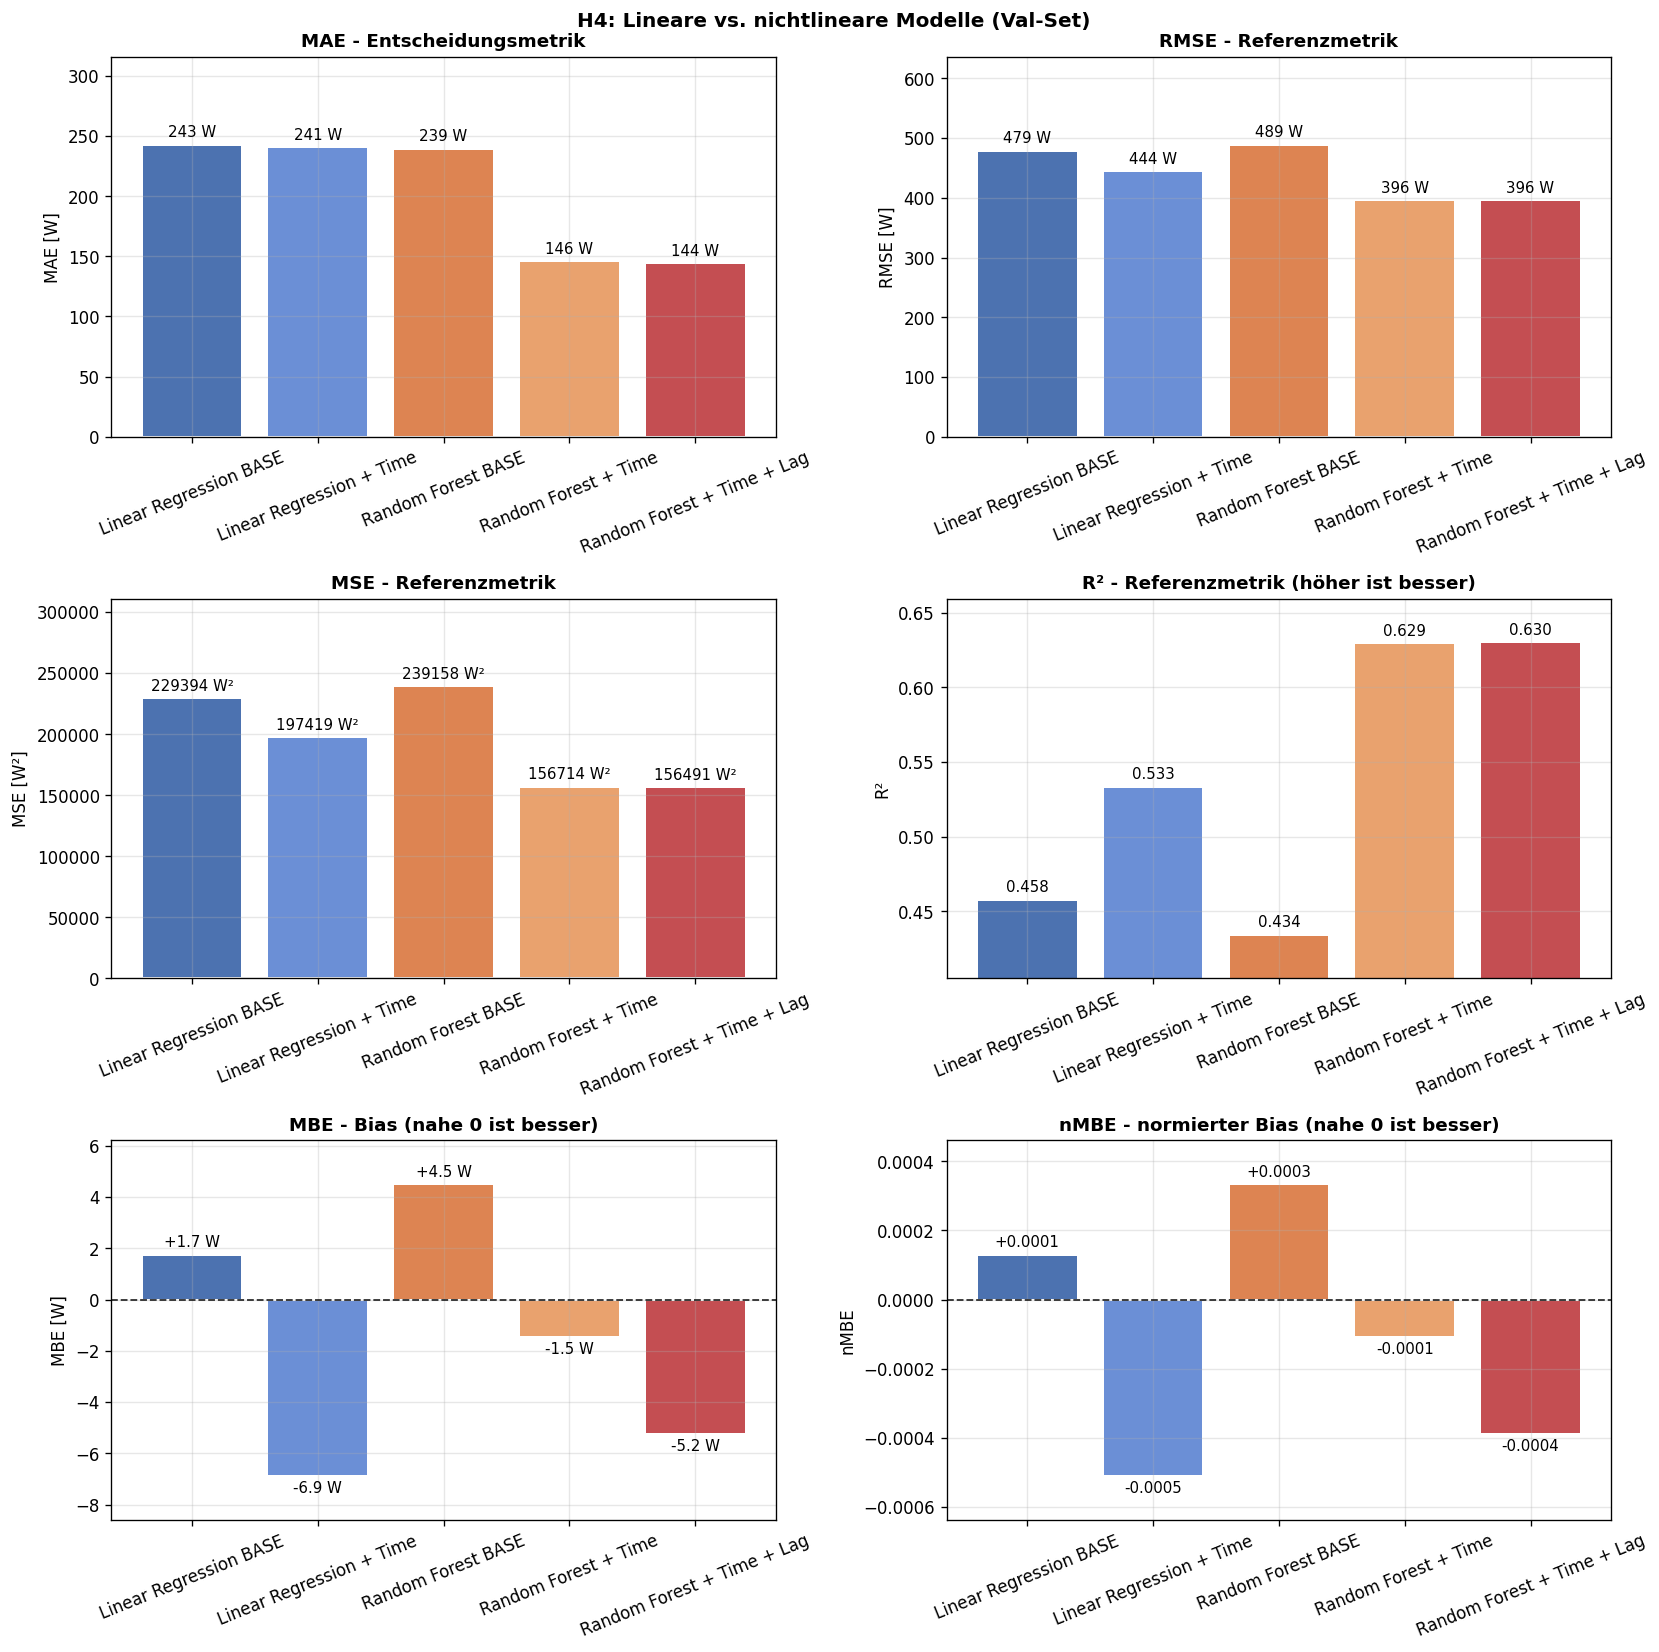

In [58]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.ravel()

metric_specs = [
    ('MAE [W]', 'MAE - Entscheidungsmetrik', '%.0f W'),
    ('RMSE [W]', 'RMSE - Referenzmetrik', '%.0f W'),
    ('MSE [W²]', 'MSE - Referenzmetrik', '%.0f W²'),
    ('R²', 'R² - Referenzmetrik (höher ist besser)', '%.3f'),
    ('MBE [W]', 'MBE - Bias (nahe 0 ist besser)', '%+.1f W'),
    ('nMBE', 'nMBE - normierter Bias (nahe 0 ist besser)', '%+.4f'),
]

for ax, (metric_col, title, label_fmt) in zip(axes, metric_specs):
    values = [summary.loc[m, metric_col] for m in MODEL_ORDER]
    colors = [MODEL_COLORS[m] for m in MODEL_ORDER]
    bars = ax.bar(MODEL_ORDER, values, color=colors, edgecolor='white', linewidth=1.2)
    ax.bar_label(bars, fmt=label_fmt, padding=3, fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel(metric_col)
    ax.tick_params(axis='x', rotation=22)

    y_min = min(values)
    y_max = max(values)
    span = y_max - y_min

    if metric_col in ('MBE [W]', 'nMBE'):
        pad = max(max(abs(y_min), abs(y_max)) * 0.25, 1e-4)
        lower = min(y_min - pad, -pad)
        upper = max(y_max + pad, pad)
        ax.set_ylim(lower, upper)
        ax.axhline(0, color='black', linestyle='--', linewidth=1.1, alpha=0.8)
    elif metric_col == 'R²':
        pad = max(span * 0.15, 0.01)
        ax.set_ylim(y_min - pad, y_max + pad)
    else:
        ax.set_ylim(0, max(values) * 1.30)

fig.suptitle('H4: Lineare vs. nichtlineare Modelle (Val-Set)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 – Verteilung der Fehlerdifferenzen

Positive Werte bedeuten: nichtlineares Modell besser als lineares Modell.

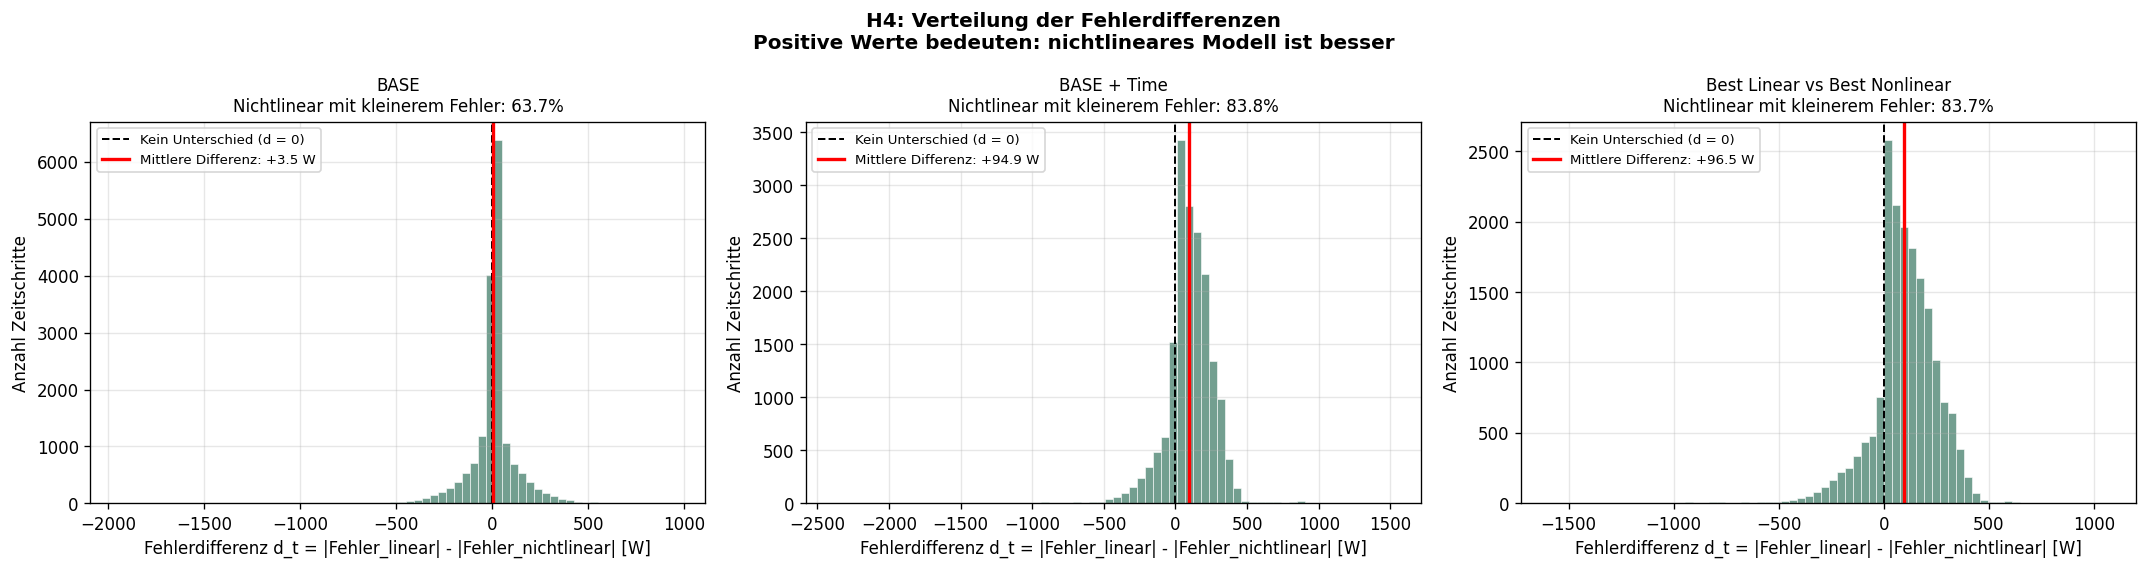

In [59]:
n_cmp = len(PAIRINGS)
fig, axes = plt.subplots(1, n_cmp, figsize=(6 * n_cmp, 4.8))
axes = np.atleast_1d(axes)

for ax, (cmp_name, linear_name, nonlinear_name) in zip(axes, PAIRINGS):
    d = diffs[cmp_name].dropna()
    mean_d = d.mean()
    pct_nonlin_better = (d > 0).mean() * 100

    ax.hist(d, bins=70, color='#5B8E7D', edgecolor='white', linewidth=0.4, alpha=0.85)
    ax.axvline(0, color='black', lw=1.2, ls='--', label='Kein Unterschied (d = 0)')
    ax.axvline(mean_d, color='red', lw=2.0, label=f'Mittlere Differenz: {mean_d:+.1f} W')
    ax.set_title(
        f"{cmp_name}\nNichtlinear mit kleinerem Fehler: {pct_nonlin_better:.1f}%",
        fontsize=10,
    )
    ax.set_xlabel('Fehlerdifferenz d_t = |Fehler_linear| - |Fehler_nichtlinear| [W]')
    ax.set_ylabel('Anzahl Zeitschritte')
    ax.legend(fontsize=8)

fig.suptitle(
    'H4: Verteilung der Fehlerdifferenzen\nPositive Werte bedeuten: nichtlineares Modell ist besser',
    fontsize=12,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

## 6 · Fazit

In [60]:
print('=' * 74)
print('FAZIT - H4: Lineare vs. nichtlineare Modelle')
print('=' * 74)

h4_col = f'H₄ (α={ALPHA})'
main_comparisons = ['BASE', 'BASE + Time']
all_main_confirmed = bool(compare_df.loc[main_comparisons, h4_col].fillna(False).all())

print('\n[Haupttests (Val-Set)]')
for cmp_name in compare_df.index:
    row = compare_df.loc[cmp_name]
    verdict = 'BESTÄTIGT' if row[h4_col] else 'WIDERLEGT'
    print(
        f"  {cmp_name}: mean(d)={row['mean(d) [W]']:+.2f} W, "
        f"p={row['p-Wert (1-s.)']:.4f} -> H4 {verdict}"
    )

    print(
        f"    RMSE: {row['RMSE linear [W]']:.1f} -> {row['RMSE nichtlinear [W]']:.1f} W | "
        f"MSE: {row['MSE linear [W²]']:.0f} -> {row['MSE nichtlinear [W²]']:.0f} W² | "
        f"R²: {row['R² linear']:.4f} -> {row['R² nichtlinear']:.4f}"
    )

    print(
        f"    MBE: {row['MBE linear [W]']:+.1f} -> {row['MBE nichtlinear [W]']:+.1f} W | "
        f"nMBE: {row['nMBE linear']:+.4f} -> {row['nMBE nichtlinear']:+.4f}"
    )
    print()

print('[Gesamtbewertung H4]')
if all_main_confirmed:
    print('  H4 ist im Hauptvergleich (BASE und BASE+Time) bestätigt.')
else:
    print('  H4 ist im Hauptvergleich nicht durchgaengig bestätigt.')

FAZIT - H4: Lineare vs. nichtlineare Modelle

[Haupttests (Val-Set)]
  BASE: mean(d)=+3.49 W, p=0.0005 -> H4 BESTÄTIGT
    RMSE: 479.0 -> 489.0 W | MSE: 229394 -> 239158 W² | R²: 0.4576 -> 0.4345
    MBE: +1.7 -> +4.5 W | nMBE: +0.0001 -> +0.0003

  BASE + Time: mean(d)=+94.89 W, p=0.0000 -> H4 BESTÄTIGT
    RMSE: 444.3 -> 395.9 W | MSE: 197419 -> 156714 W² | R²: 0.5332 -> 0.6294
    MBE: -6.9 -> -1.5 W | nMBE: -0.0005 -> -0.0001

  Best Linear vs Best Nonlinear: mean(d)=+96.53 W, p=0.0000 -> H4 BESTÄTIGT
    RMSE: 444.3 -> 395.6 W | MSE: 197419 -> 156491 W² | R²: 0.5332 -> 0.6300
    MBE: -6.9 -> -5.2 W | nMBE: -0.0005 -> -0.0004

[Gesamtbewertung H4]
  H4 ist im Hauptvergleich (BASE und BASE+Time) bestätigt.
